# Proposer pilot

Manually build a small trajectory graph, score each `(origin, target)` task with a solver, and eyeball whether origin→leaf paths look like sensible proposer training tasks.

In [1]:
%load_ext autoreload
%autoreload 2

from wandering_light.common_functions import basic_fns
from wandering_light.proposer_pilot import TrajectoryGraph, SolveRater
from wandering_light.solver import create_bfs_solver
from wandering_light.typed_list import TypedList

[fn.name for fn in basic_fns][:20]

/home/user/wandering-light/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/user/wandering-light/wandering_light/solver.py:13: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


['inc',
 'dec',
 'double',
 'half',
 'square',
 'mod2',
 'neg',
 'abs',
 'sign',
 'f_reciprocal',
 'f_abs_sqrt',
 'f_fraction',
 'f_trunc',
 'f_round',
 'f_mod1',
 'upper',
 'lower',
 'capitalize',
 'title',
 'strip']

## 1. Build a graph by hand
Seed with a couple of root states, then `apply_by_name(parent_id, fn_name)` to walk.

In [2]:
g = TrajectoryGraph()  # default basic_fns

r1 = g.add_root(TypedList([1, 2, 3], item_type=int))
r2 = g.add_root(TypedList(["hello", "world"], item_type=str))

n_inc = g.apply_by_name(r1, "inc")
n_inc2 = g.apply_by_name(n_inc, "inc")
n_dbl = g.apply_by_name(r1, "double")

n_upper = g.apply_by_name(r2, "upper")
n_len = g.apply_by_name(r2, "length")

print(f"nodes={g.num_nodes()} edges={g.num_edges()} roots={g.roots}")
for node in g.nodes():
    print(f"  [{node.id}] {node.typed_list}")

nodes=7 edges=5 roots=[0, 1]
  [0] TL<int>([1, 2, 3])
  [1] TL<str>(['hello', 'world'])
  [2] TL<int>([2, 3, 4])
  [3] TL<int>([3, 4, 5])
  [4] TL<int>([2, 4, 6])
  [5] TL<str>(['HELLO', 'WORLD'])
  [6] TL<int>([5, 5])


## 2. Enumerate candidate tasks
Each task wraps a `Trajectory` (input, function_defs, output). The graph collapses paths that land on the same state, so `num_steps` is the BFS-shortest known route.

In [3]:
tasks = list(g.tasks(min_steps=1))
for t in tasks:
    fns = ", ".join(fn.name for fn in t.trajectory.function_defs)
    print(f"{t.trajectory.input}  ->  {t.trajectory.output}    [{t.num_steps} step(s): {fns}]")

TL<int>([1, 2, 3])  ->  TL<int>([2, 3, 4])    [1 step(s): inc]
TL<int>([1, 2, 3])  ->  TL<int>([2, 4, 6])    [1 step(s): double]
TL<int>([1, 2, 3])  ->  TL<int>([3, 4, 5])    [2 step(s): inc, inc]
TL<str>(['hello', 'world'])  ->  TL<str>(['HELLO', 'WORLD'])    [1 step(s): upper]
TL<str>(['hello', 'world'])  ->  TL<int>([5, 5])    [1 step(s): length]


## 3. Score with a solver
Default rater uses BFS. Swap in any `TrajectorySolver` (e.g., trained LLM) to compare difficulty under different solvers.

In [4]:
rater = SolveRater(solver=create_bfs_solver(budget=200, max_depth=4))
results = rater.rate_tasks(tasks)

for t, r in zip(tasks, results):
    print(f"rate={r.rate:.2f}  steps={t.num_steps}  {t.trajectory.input} -> {t.trajectory.output}")

rate=1.00  steps=1  TL<int>([1, 2, 3]) -> TL<int>([2, 3, 4])
rate=1.00  steps=1  TL<int>([1, 2, 3]) -> TL<int>([2, 4, 6])
rate=1.00  steps=2  TL<int>([1, 2, 3]) -> TL<int>([3, 4, 5])
rate=1.00  steps=1  TL<str>(['hello', 'world']) -> TL<str>(['HELLO', 'WORLD'])
rate=1.00  steps=1  TL<str>(['hello', 'world']) -> TL<int>([5, 5])


## 4. Visualize
Quick networkx draw — fine for ~20 nodes. For richer interaction, port to a Streamlit page later.

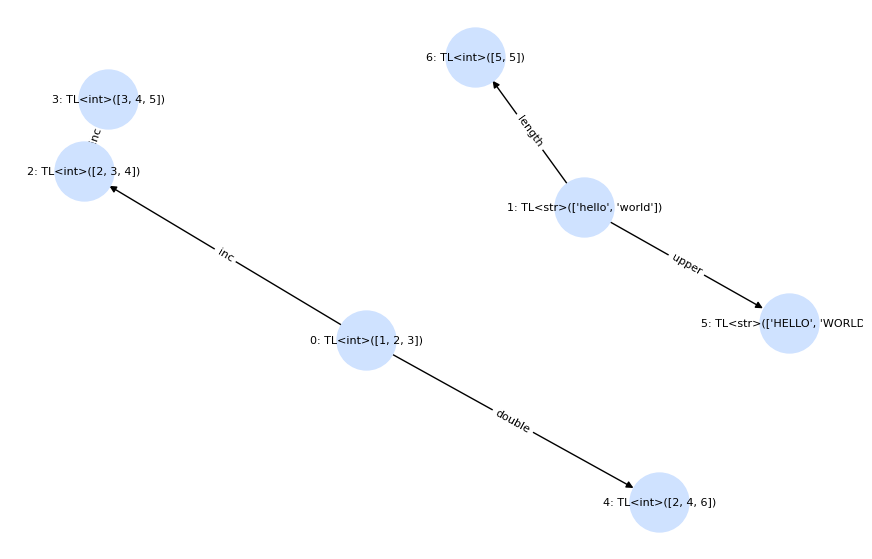

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

nxg = g.to_networkx()
pos = nx.spring_layout(nxg, seed=0)
labels = {n: f"{n}: {nxg.nodes[n]['typed_list']}" for n in nxg.nodes}
edge_labels = {(u, v, k): d["fn"] for u, v, k, d in nxg.edges(keys=True, data=True)}

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw(nxg, pos, with_labels=True, labels=labels, node_color="#cfe2ff", node_size=1800, font_size=8, ax=ax)
nx.draw_networkx_edge_labels(nxg, pos, edge_labels={(u, v): d["fn"] for u, v, _, d in nxg.edges(keys=True, data=True)}, font_size=8, ax=ax)
plt.show()

## 5. Eyeball check
For each task, ask: would I want the proposer to learn to generate this? Look for:
- All `rate==1.0`: too easy, no curriculum signal.
- All `rate==0.0`: too hard or unreachable; the solver isn't strong enough to validate.
- Mixed rates with steps in $[1,3]$: that's the frontier you want to mine for proposer training.